In [ ]:
#!/usr/bin/env python3

from pathlib import Path
import pandas as pd
import networkx as nx
import numpy as np


def parse_gfa(gfa_path):

    nodes = {}
    edges = []

    with open(gfa_path) as f:
        for line in f:

            if line.startswith("S"):
                parts = line.strip().split("\t")

                node_id = parts[1]
                seq = parts[2]

                nodes[node_id] = {
                    "length": len(seq)
                }

            elif line.startswith("L"):
                parts = line.strip().split("\t")

                source = parts[1]
                target = parts[3]

                edges.append((source, target))

    return nodes, edges


def build_graph(nodes, edges, only_largest_component : bool = False):

    G = nx.Graph()

    for node, data in nodes.items():
        G.add_node(node, **data)

    G.add_edges_from(edges)
    
    if only_largest_component:
        largest_nodes = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_nodes).copy()

    return G


def compute_metrics(G):

    node_lengths = np.array([d["length"] for _, d in G.nodes(data=True)])

    degrees = np.array([d for _, d in G.degree()])

    branching_nodes = (degrees > 2).sum()

    metrics = {
        "n_nodes": G.number_of_nodes(),
        "n_edges": G.number_of_edges(),
        "total_sequence_length": node_lengths.sum(),
        "mean_node_length": node_lengths.mean(),
        "median_node_length": np.median(node_lengths),
        "mean_degree": degrees.mean(),
        "max_degree": degrees.max(),
        "branching_nodes": branching_nodes,
        "branching_fraction": branching_nodes / G.number_of_nodes()
    }

    return pd.DataFrame([metrics])

def node_table(G):

    rows = []

    for node, data in G.nodes(data=True):

        degree = G.degree(node)

        rows.append({
            "node": node,
            "length": data["length"],
            "degree": degree,
            "branching": degree > 2,
            "terminal": degree == 1
        })

    df = pd.DataFrame(rows)

    df.to_csv("node_metrics.tsv", sep="\t", index=False)

    return df

def component_table(G):

    rows = []

    for i, comp in enumerate(nx.connected_components(G)):

        sub = G.subgraph(comp)

        rows.append({
            "component": i,
            "n_nodes": sub.number_of_nodes(),
            "n_edges": sub.number_of_edges(),
            "total_length": sum(d["length"] for _, d in sub.nodes(data=True))
        })

    df = pd.DataFrame(rows)

    df.to_csv("component_metrics.tsv", sep="\t", index=False)

    return df


def main(gfa):

    nodes, edges = parse_gfa(gfa)

    G = build_graph(nodes, edges, only_largest_component = True)
    node_table(G)
    component_table(G)

    metrics = compute_metrics(G)

    print(metrics)

    metrics.to_csv("graph_metrics.tsv", sep="\t", index=False)
    return(G)

if __name__ == "__main__":

    import argparse
    dev_mode=True
    if dev_mode:
        gfa = '/home/jpereira/AAGrafos/entrega/graphs/grch38_hprc_r2.minigraph2.gfa'
    else:
        
        parser = argparse.ArgumentParser()
        parser.add_argument("gfa")

        args = parser.parse_args()
        gfa = args.gfa

    G=main(gfa)

   n_nodes  n_edges  total_sequence_length  mean_node_length  \
0   143651   206724             3135900503      21829.994243   

   median_node_length  mean_degree  max_degree  branching_nodes  \
0               161.0     2.878142          15            71332   

   branching_fraction  
0            0.496565  


In [15]:
pd.read_csv('graph_metrics.tsv', sep='\t')

,n_nodes,n_edges,total_sequence_length,mean_node_length,median_node_length,mean_degree,max_degree,branching_nodes,branching_fraction
0,143651,206724,3135900503,21829.994243,161.0,2.878142,15,71332,0.496565


In [ ]:
largest_nodes = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_nodes).copy()

print("Original graph:")
print("  nodes:", G.number_of_nodes())
print("  edges:", G.number_of_edges())

print("Largest connected component:")
print("  nodes:", G_lcc.number_of_nodes())
print("  edges:", G_lcc.number_of_edges())

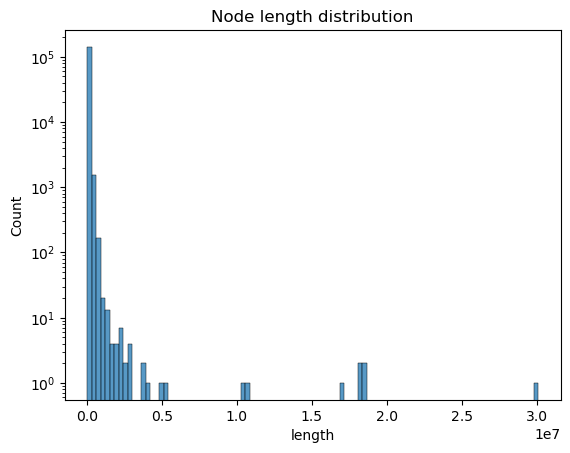

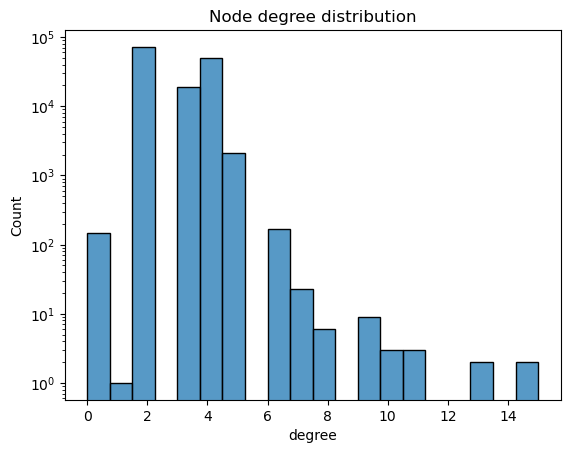

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

figs_dir = Path('figs')
figs_dir.mkdir(exist_ok=True)

df = pd.read_csv("node_metrics.tsv", sep="\t")

sns.histplot(df["length"], bins=100)
plt.yscale("log")
plt.title("Node length distribution")

# A nivel general se observa que mayoría de los 
plt.savefig(figs_dir / 'node_length_distribution.png')
plt.show()

sns.histplot(df["degree"], bins=20)
plt.yscale("log")
plt.title("Node degree distribution")
plt.savefig(figs_dir / 'node_degree_distribution.png')
plt.show()

Text(0.5, 1.0, 'Node length distribution')

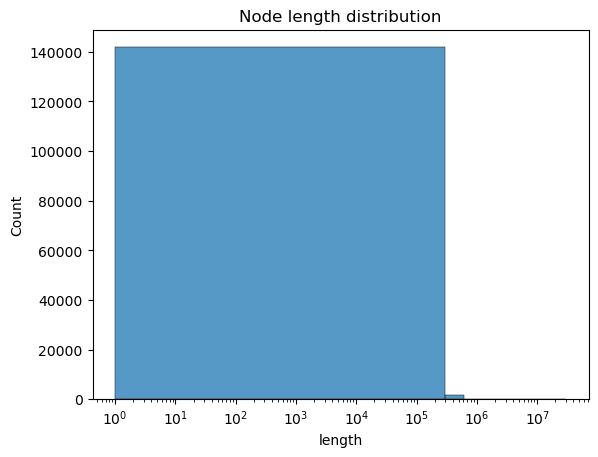

In [5]:
sns.histplot(df["length"], bins=100)
plt.xscale("log")
plt.title("Node length distribution")

Text(0.5, 1.0, 'Node degree distribution')

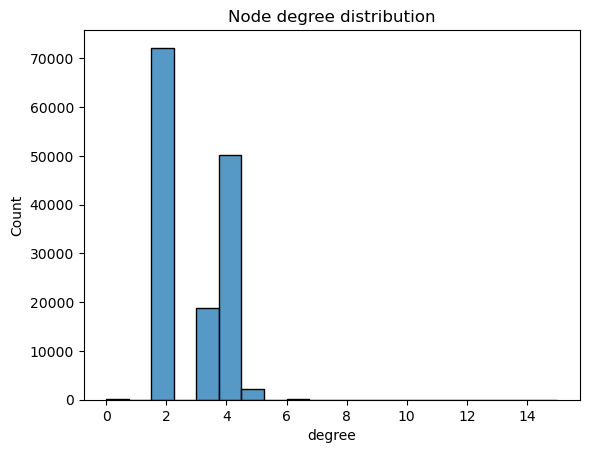

In [6]:
sns.histplot(df["degree"], bins=20)
plt.title("Node degree distribution")

<Axes: xlabel='n_nodes', ylabel='Count'>

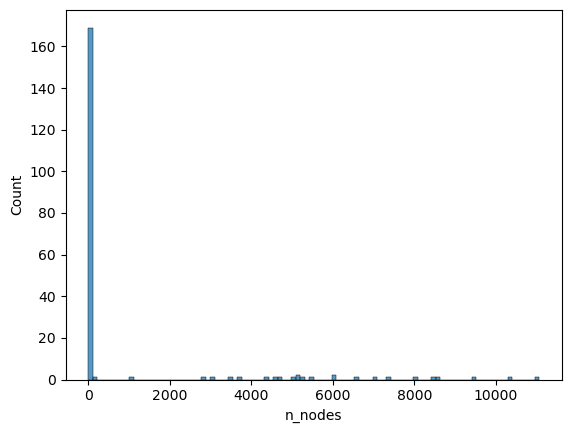

In [13]:
component_df = pd.read_csv('/home/jpereira/AAGrafos/entrega/component_metrics.tsv', sep='\t')

sns.histplot(component_df["n_nodes"], bins=100)
#plt.xscale("log")

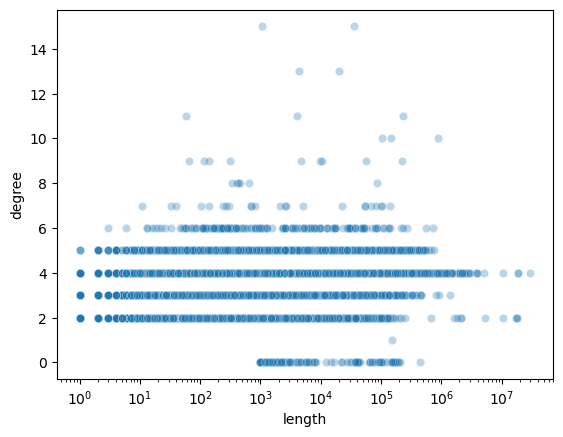

In [8]:
branch_nodes = df[df["branching"]]
sns.scatterplot(data=df, x="length", y="degree", alpha=0.3)
plt.xscale("log")

In [9]:
ap = list(nx.articulation_points(G))

len(ap)

44138

In [10]:
bridges = list(nx.bridges(G))

pd.DataFrame(bridges, columns=["node1","node2"]).to_csv(
    "bridge_edges.tsv",
    sep="\t",
    index=False
)

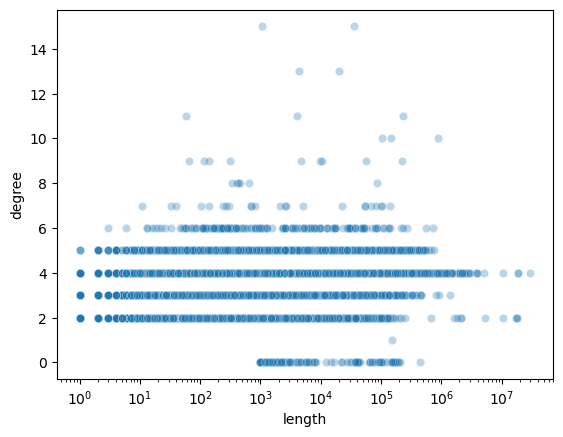

In [11]:
sns.scatterplot(data=df, x="length", y="degree", alpha=0.3)
plt.xscale("log")